In [4]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250407_211101_vae.pth"
vae = VAE(latent_dim=latent_dim).to(device)  # Match latent_dim to your model

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()  # Set to evaluation mode


/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_3951/3853959274.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
  )
  (mean_layer): Linear(in_features=64, out_features=2, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=100, bias=True)
  )
)

In [5]:
data = pd.read_pickle("../data/outlier_removed.pkl")  

In [6]:
import pandas as pd
import torch

data = pd.read_pickle("../data/outlier_removed.pkl")

downsampled_data = data['downsampled_time_series'].values

downsampled_tensor = torch.tensor(downsampled_data.tolist(), dtype=torch.float32).to(device)

def get_latent_vectors(vae, data_tensor):
    vae.eval()  
    with torch.no_grad():  
        encoder_output = vae.encoder(data_tensor)
        return encoder_output.cpu().numpy()

# add the latent vectors to the dataframe
latent_vectors = get_latent_vectors(vae, downsampled_tensor)

data['vae_latent_space'] = list(latent_vectors)

In [7]:
def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()


In [8]:
means, stds, latents = get_latent_stats(vae, downsampled_tensor)

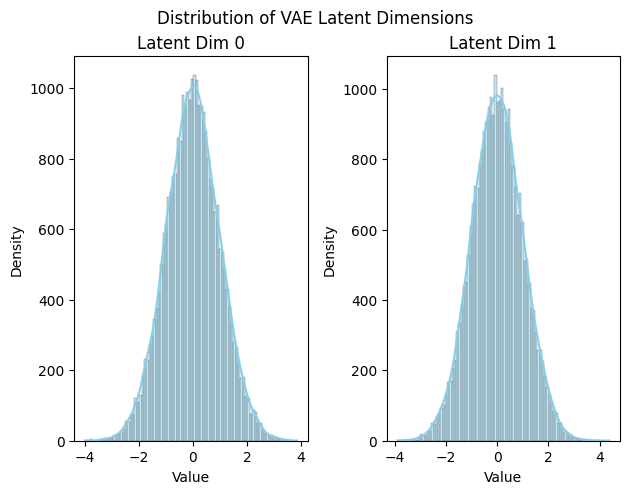

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

latent_dim = latents.shape[1]
fig, axs = plt.subplots(nrows=1, ncols=2) 
# axs = axs.flatten()

for i in range(latent_dim):
    sns.histplot(latents[:, i], kde=True, ax=axs[i], color="skyblue")
    axs[i].set_title(f"Latent Dim {i}")
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Density")

plt.tight_layout()
plt.suptitle("Distribution of VAE Latent Dimensions", fontsize=12, y=1.02)
plt.show()


In [36]:
import matplotlib.pyplot as plt

def plot_single_reconstruction(vae, data_tensor, index=2):
    vae.eval()
    with torch.no_grad():
        x = data_tensor[index].unsqueeze(0)  # batch dim
        x_hat, _, _ = vae(x)

    original = x.squeeze().cpu().numpy()
    reconstructed = x_hat.squeeze().cpu().numpy()

    plt.figure(figsize=(8, 6))
    plt.plot(original, label="Original", color="blue")
    plt.plot(reconstructed, label="Reconstructed", color="orange", linestyle='--')
    plt.title(f"Original vs Reconstructed - Jump Index: {index}")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


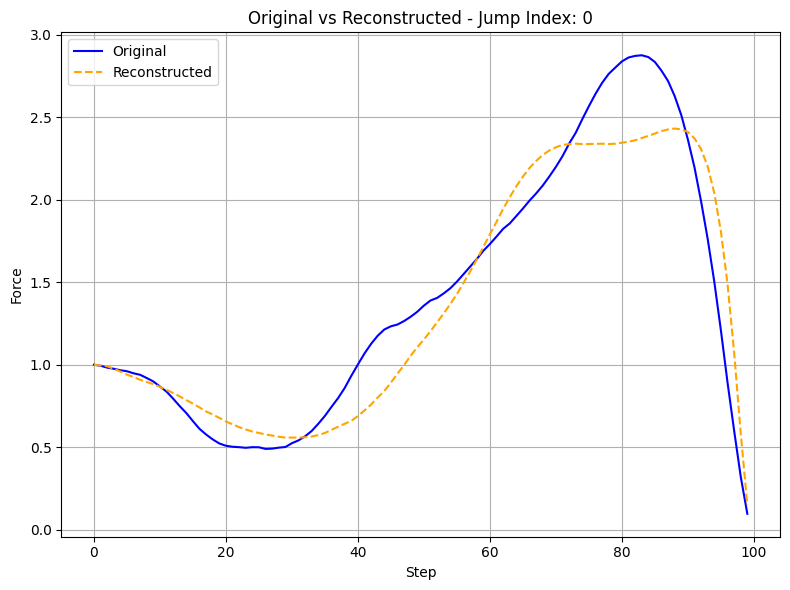

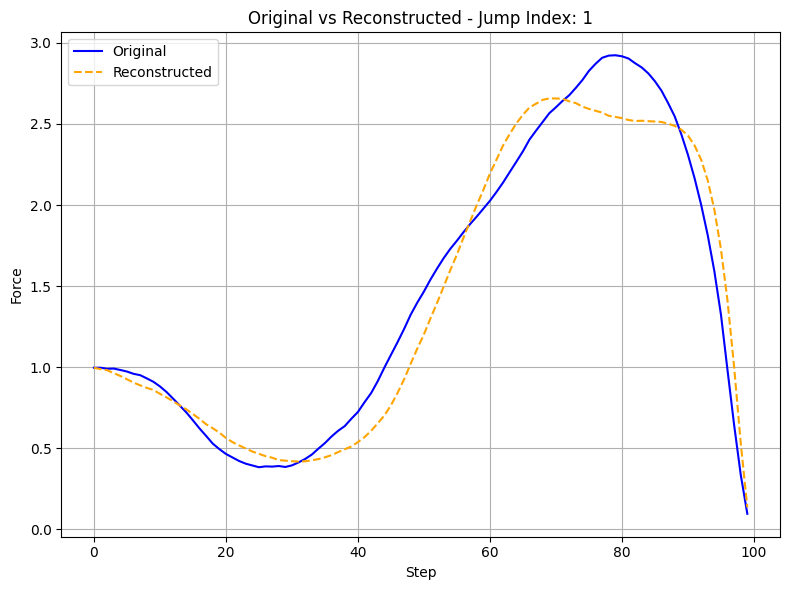

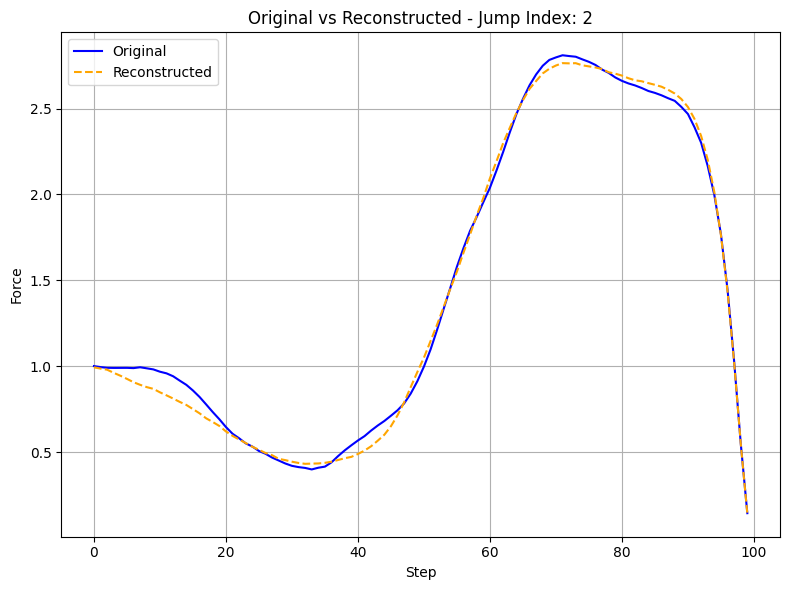

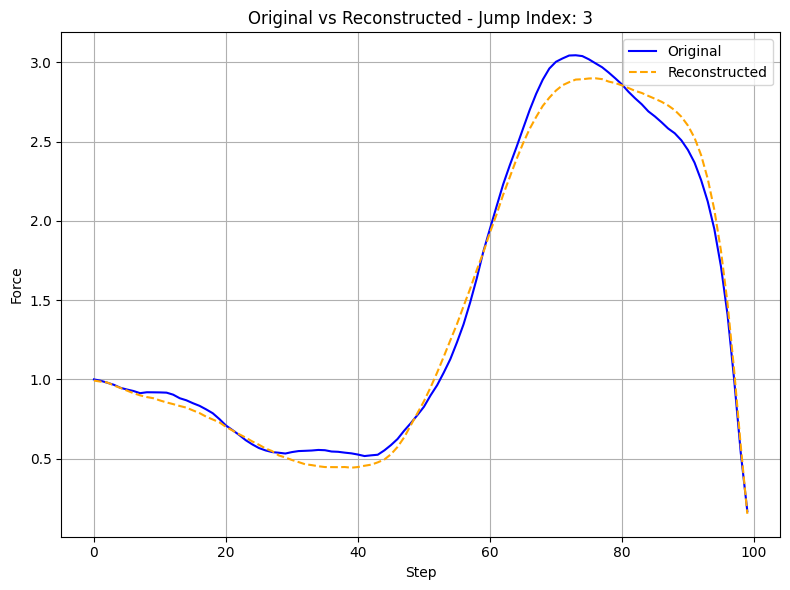

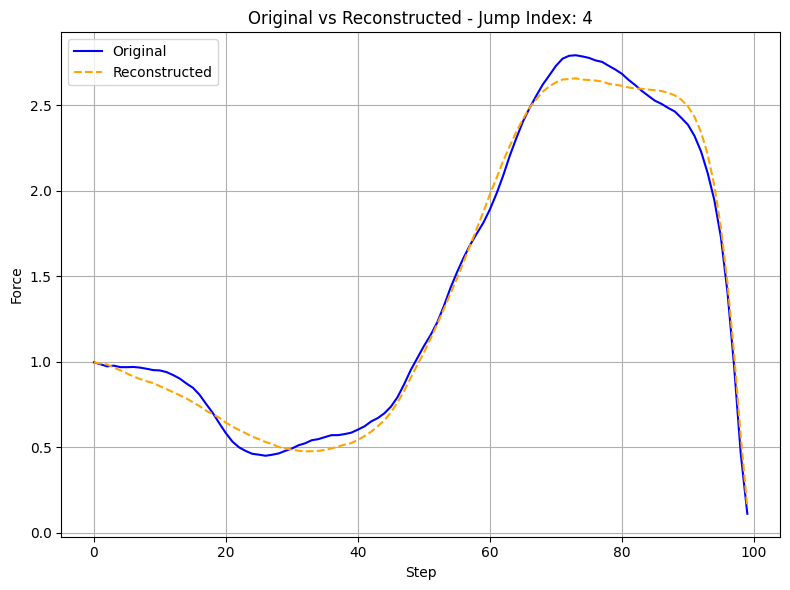

In [37]:
for i in range(5):
    plot_single_reconstruction(vae, downsampled_tensor, index=i)


In [38]:
import torch.nn.functional as F

def compute_reconstruction_errors(vae, data_tensor):
    vae.eval()
    errors = []

    with torch.no_grad():
        for x in data_tensor:
            x = x.unsqueeze(0)  # batch dim
            x_hat, _, _ = vae(x)
            mse = F.mse_loss(x_hat, x).item()
            errors.append(mse)

    return errors


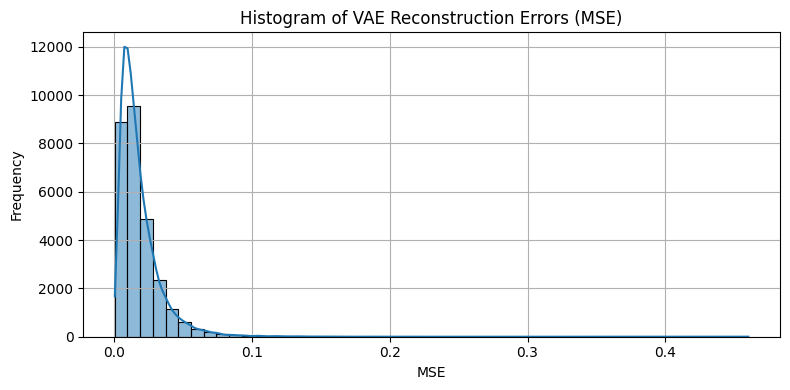

Mean MSE: 0.0184
Median MSE: 0.0141


In [39]:
errors = compute_reconstruction_errors(vae, downsampled_tensor)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=50, kde=True)
plt.title("Histogram of VAE Reconstruction Errors (MSE)")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean MSE: {np.mean(errors):.4f}")
print(f"Median MSE: {np.median(errors):.4f}")


In [40]:
def get_2d_latent_vectors(vae, data_tensor):
    """
    Encodes the data using VAE and returns 2D latent vectors.
    """
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return z.cpu().numpy()

latent_vectors_2d = get_2d_latent_vectors(vae, downsampled_tensor)

data['vae_latent_space_2d'] = list(latent_vectors_2d)


In [41]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space,vae_latent_space_2d
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,519.440318,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.03022992, -0.024856891, -0.06593302, -0.01...","[-1.3728888, -1.0951293]"


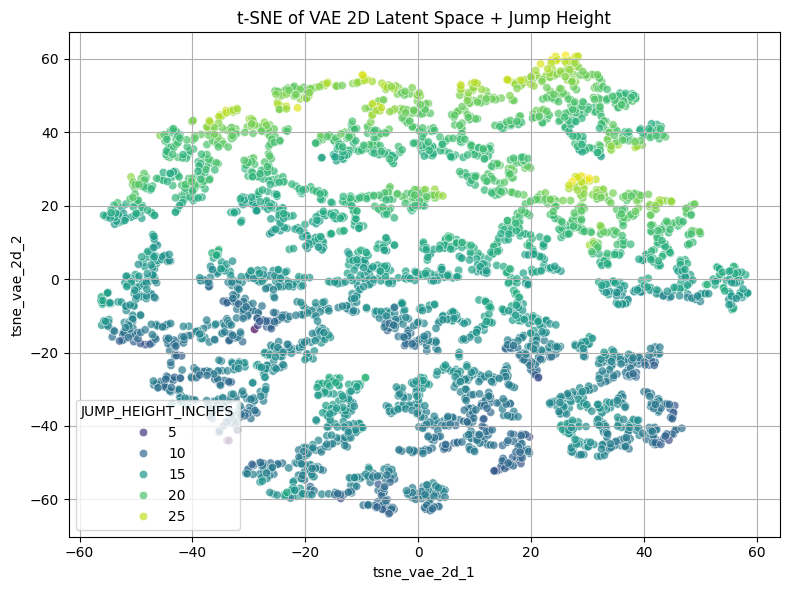

In [47]:
jump_features = ["JUMP_HEIGHT_INCHES"]

sampled_df = data.sample(n=4000, random_state=42)

scaler = StandardScaler()
feature_matrix = scaler.fit_transform(sampled_df[jump_features])

latent_matrix_2d = np.stack(sampled_df["vae_latent_space_2d"].values)

combined_matrix_2d = np.hstack((latent_matrix_2d, feature_matrix))

tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42)
combined_tsne_2d = tsne_2d.fit_transform(combined_matrix_2d)

sampled_df["tsne_vae_2d_1"] = combined_tsne_2d[:, 0]
sampled_df["tsne_vae_2d_2"] = combined_tsne_2d[:, 1]


plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="tsne_vae_2d_1", y="tsne_vae_2d_2", 
    data=sampled_df, alpha=0.7, 
    hue="JUMP_HEIGHT_INCHES", palette="viridis"
)
plt.title("t-SNE of VAE 2D Latent Space + Jump Height")
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Sample data (same 4000 rows you used for t-SNE)
sampled_df = data.sample(n=4000, random_state=42)

# Extract 2D latent space features and reset index
X_latent_2d = np.stack(sampled_df["vae_latent_space_2d"].values)
X_df = pd.DataFrame(X_latent_2d, columns=["Latent1", "Latent2"]).reset_index(drop=True)

# Reset index of target variable
y = sampled_df["JUMP_HEIGHT_INCHES"].reset_index(drop=True)

# Add intercept
X_with_const = sm.add_constant(X_df)

# Fit the model
model = sm.OLS(y, X_with_const).fit()

# Show regression results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     JUMP_HEIGHT_INCHES   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5350
Date:                Mon, 07 Apr 2025   Prob (F-statistic):              0.586
Time:                        21:43:18   Log-Likelihood:                -11108.
No. Observations:                4000   AIC:                         2.222e+04
Df Residuals:                    3997   BIC:                         2.224e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.0126      0.062    260.326      0.0